### Cell 1: Import thư viện và các module đã tách

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Import từ các file của bạn
from config import *
from data_utils import *
from model_utils import *

### Cell 2: Đọc và Xử lý dữ liệu (ETL)

In [2]:
df_fake = pd.read_csv(RAW_FAKE_PATH)
df_fake['label'] = 1
df_true = pd.read_csv(RAW_TRUE_PATH)
df_true['label'] = 0

explore_raw_data(df_fake, "TẬP TIN GIẢ (FAKE.CSV)")
explore_raw_data(df_true, "TẬP TIN THẬT (TRUE.CSV)")

df_fake['date_parsed'] = pd.to_datetime(df_fake['date'], errors='coerce')
df_true['date_parsed'] = pd.to_datetime(df_true['date'], errors='coerce')

df_fake = df_fake.dropna(subset=['text', 'date_parsed']).drop_duplicates(subset=['text'])
df_true = df_true.dropna(subset=['text', 'date_parsed']).drop_duplicates(subset=['text'])

df_fake = df_fake.sort_values('date_parsed').reset_index(drop=True)
df_true = df_true.sort_values('date_parsed').reset_index(drop=True)

df_fake['is_test'] = False
df_fake.loc[int(len(df_fake) * 0.8):, 'is_test'] = True

df_true['is_test'] = False
df_true.loc[int(len(df_true) * 0.8):, 'is_test'] = True


df = pd.concat([df_fake, df_true], axis=0)
df = df.sort_values('is_test').reset_index(drop=True)

df['text_clean_raw'] = df['text'].apply(deep_clean_text)
df['title_text_clean_raw'] = (df['title'] + " " + df['text']).apply(deep_clean_text)
df['title_clean_raw'] = df['title'].apply(deep_clean_text)

df['text_clean'] = df['text_clean_raw'].apply(lemmatize_and_remove_stopwords)
df['title_text_clean'] = df['title_text_clean_raw'].apply(lemmatize_and_remove_stopwords)
df['title_clean'] = df['title_clean_raw'].apply(lemmatize_and_remove_stopwords)

# Xóa trùng lặp sâu
df = df.drop_duplicates(subset=['text_clean'], keep='first').reset_index(drop=True)
df = df[df['text_clean'].str.strip() != ""].reset_index(drop=True)

train_idx = df[df['is_test'] == False].index
test_idx = df[df['is_test'] == True].index
y_train = df.loc[train_idx, 'label']
y_test = df.loc[test_idx, 'label']

df.drop(columns=['subject', 'date', 'date_parsed', 'is_test'], inplace=True, errors='ignore')

explore_processed_data(df, train_idx, test_idx)

test_idx = remove_data_leakage_from_test(df, train_idx, test_idx, clean_col='text_clean')
y_test = df.loc[test_idx, 'label']

processed_dir = os.path.dirname(PROCESSED_DATA_PATH)
os.makedirs(processed_dir, exist_ok=True)
print(f"\n⏳ Đang lưu tập dữ liệu đã xử lý ra file CSV (có thể mất vài phút)...")
df.to_csv(PROCESSED_DATA_PATH, index=False, encoding='utf-8')
print(f"✅ Đã lưu thành công tại: {PROCESSED_DATA_PATH}")
joblib.dump(train_idx, os.path.join(processed_dir, 'train_idx.pkl'))
joblib.dump(test_idx, os.path.join(processed_dir, 'test_idx.pkl'))
print(f"✅ Đã lưu file chia index (train_idx, test_idx) thành công!")

📊 THỐNG KÊ DỮ LIỆU THÔ: TẬP TIN GIẢ (FAKE.CSV)
1. Kích thước tập dữ liệu:
   - Số dòng (Bài báo): 23,481
   - Số cột (Đặc trưng): 5

2. Số lượng giá trị thiếu (Missing Values):
   -> Tuyệt vời! Không có giá trị nào bị thiếu.

3. Số lượng dòng trùng lặp (Duplicates):
   -> Phát hiện 3 dòng bị trùng lặp hoàn toàn trên toàn bộ cột.

4. Danh sách các cột và kiểu dữ liệu:
   - title           : str
   - text            : str
   - subject         : str
   - date            : str
   - label           : int64


📊 THỐNG KÊ DỮ LIỆU THÔ: TẬP TIN THẬT (TRUE.CSV)
1. Kích thước tập dữ liệu:
   - Số dòng (Bài báo): 21,417
   - Số cột (Đặc trưng): 5

2. Số lượng giá trị thiếu (Missing Values):
   -> Tuyệt vời! Không có giá trị nào bị thiếu.

3. Số lượng dòng trùng lặp (Duplicates):
   -> Phát hiện 206 dòng bị trùng lặp hoàn toàn trên toàn bộ cột.

4. Danh sách các cột và kiểu dữ liệu:
   - title           : str
   - text            : str
   - subject         : str
   - date            : str
   - label

### Cell 3: Phân tích EDA

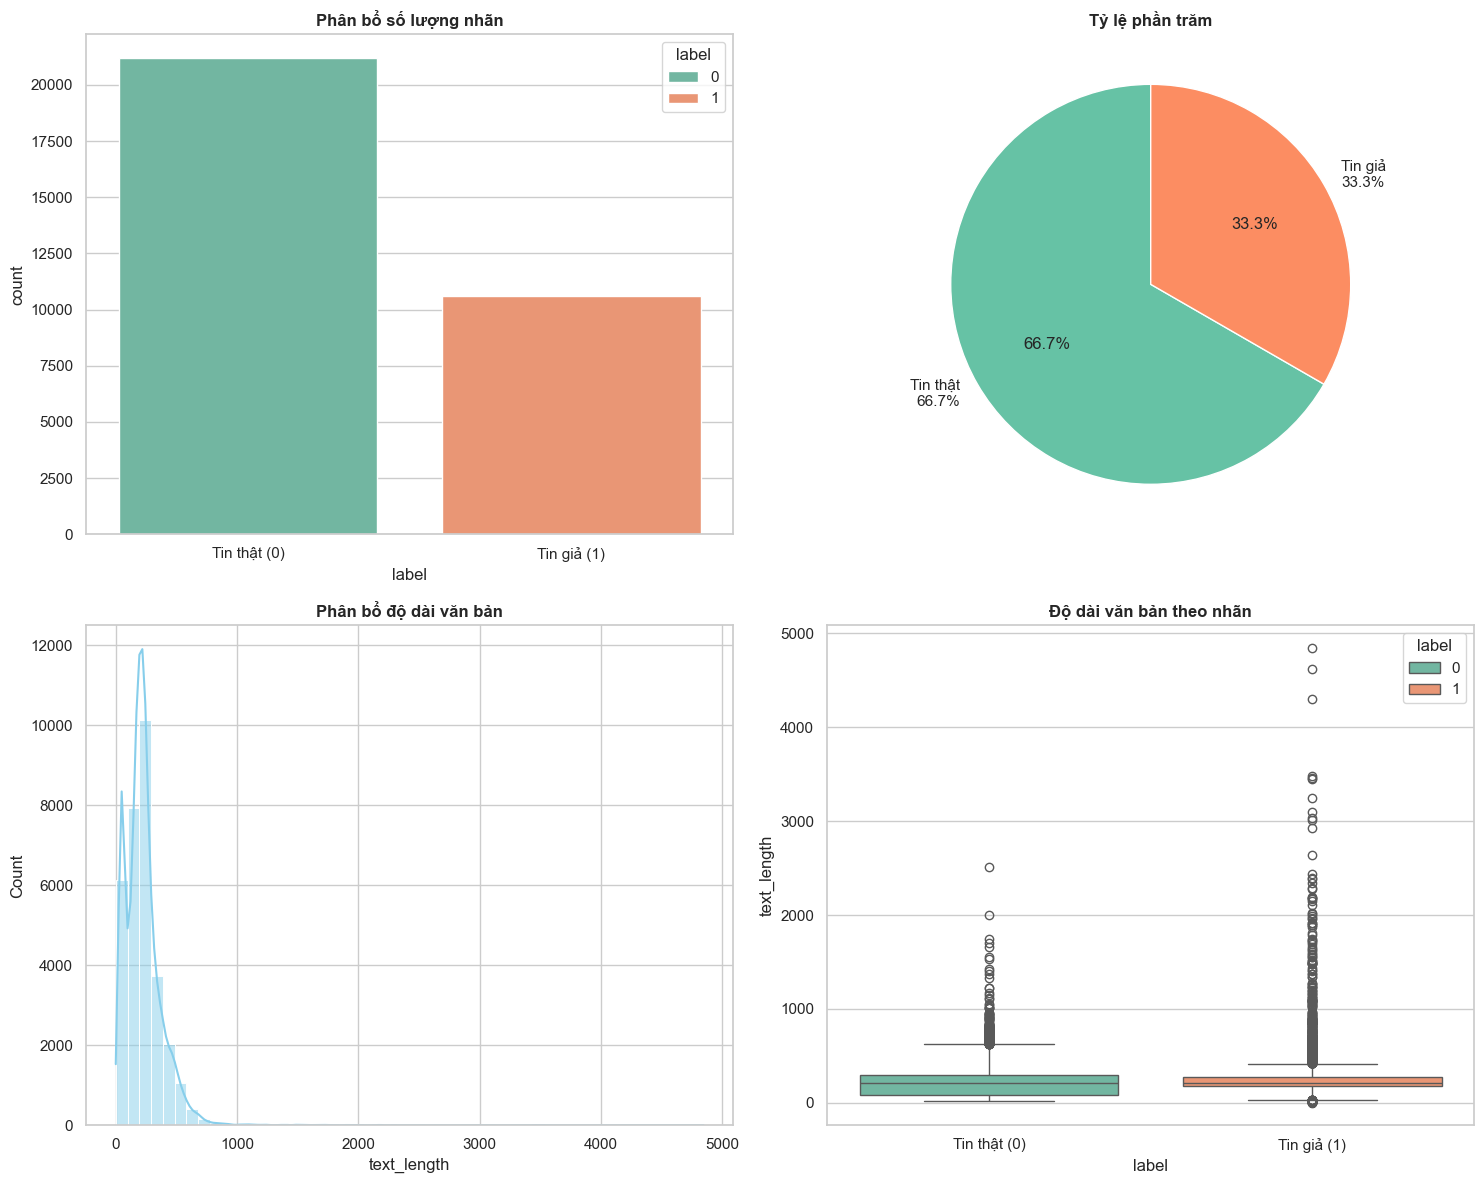

In [3]:
plot_eda(df)

### Cell 4: Xây dựng Feature Pipeline

In [4]:
X_train_text, X_test_text, tfidf_text = build_feature_pipeline(df, train_idx, test_idx, 'text_clean', 'text_clean_raw')
X_train_title_text, X_test_title_text, tfidf_title_text = build_feature_pipeline(df, train_idx, test_idx, 'title_text_clean', 'title_text_clean_raw')
X_train_title, X_test_title, tfidf_title = build_feature_pipeline(df, train_idx, test_idx, 'title_clean', 'title_clean_raw')

### Cell 5: Huấn luyện Mô hình

--- HUẤN LUYỆN LOGISTIC REGRESSION ---


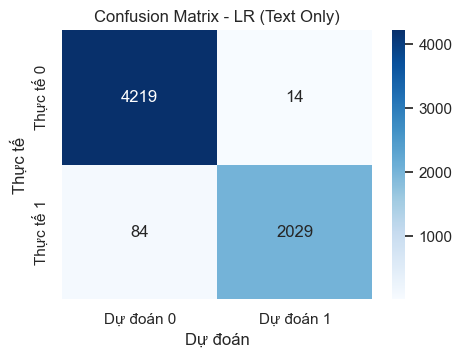

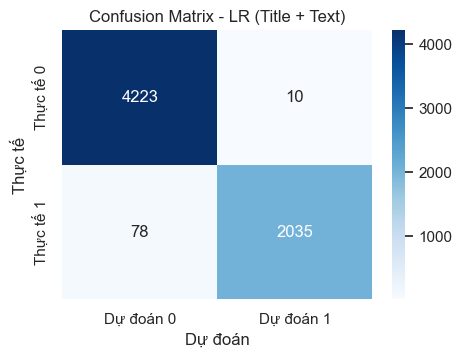

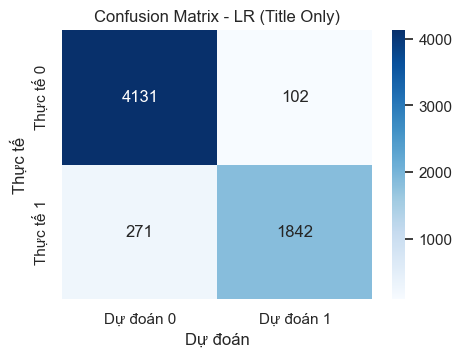

                             SO SÁNH MÔ HÌNH: LOGISTIC REGRESSION                              
Chỉ số (Metric)                   Title + Text                 Text                Title
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.982                0.980                0.938
Tin thật Recall                          0.998                0.997                0.976
Tin thật F1-score                        0.990                0.989                0.957
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.995                0.993                0.948
Tin giả Recall                           0.963                0.960                0.872
Tin giả F1-score                         0.979                0.976                0.908
-----------------------------------------------------------------------------------------

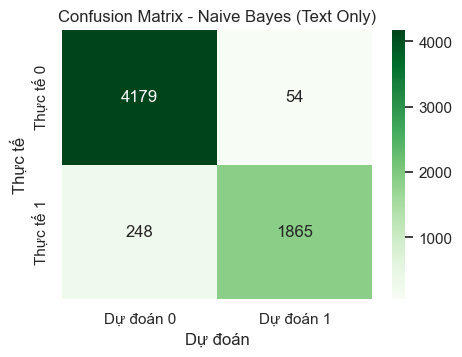

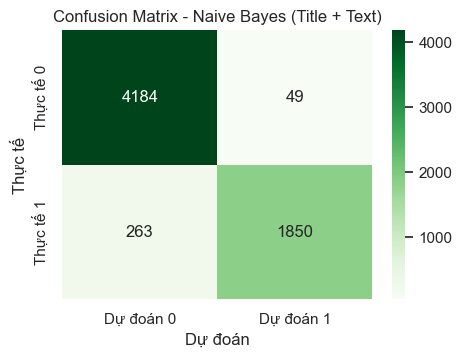

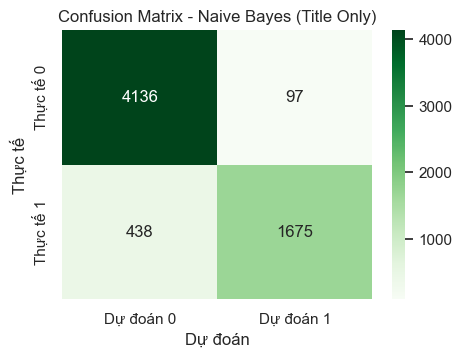

                                 SO SÁNH MÔ HÌNH: NAIVE BAYES                                  
Chỉ số (Metric)                   Title + Text                 Text                Title
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.941                0.944                0.904
Tin thật Recall                          0.988                0.987                0.977
Tin thật F1-score                        0.964                0.965                0.939
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.974                0.972                0.945
Tin giả Recall                           0.876                0.883                0.793
Tin giả F1-score                         0.922                0.925                0.862
-----------------------------------------------------------------------------------------

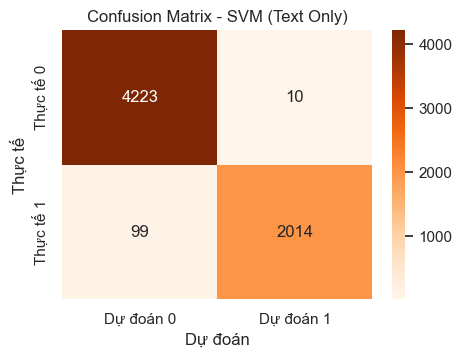

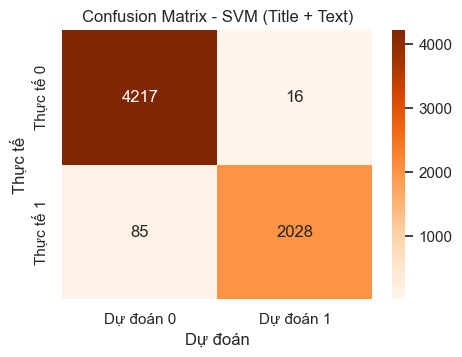

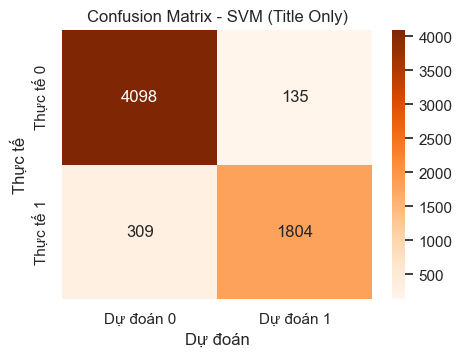

                                     SO SÁNH MÔ HÌNH: SVM                                      
Chỉ số (Metric)                   Title + Text                 Text                Title
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.980                0.977                0.930
Tin thật Recall                          0.996                0.998                0.968
Tin thật F1-score                        0.988                0.987                0.949
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.992                0.995                0.930
Tin giả Recall                           0.960                0.953                0.854
Tin giả F1-score                         0.976                0.974                0.890
-----------------------------------------------------------------------------------------

In [5]:
all_results = []

# ==========================================
# 1. LOGISTIC REGRESSION
# ==========================================
print("--- HUẤN LUYỆN LOGISTIC REGRESSION ---")
lr_model_text = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model_title_text = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model_title = LogisticRegression(max_iter=1000, class_weight='balanced')

acc_lr_text, rep_lr_text = train_and_evaluate_model(lr_model_text, "LR (Text Only)", X_train_text, y_train, X_test_text, y_test, "Blues")
acc_lr_title_text, rep_lr_title_text = train_and_evaluate_model(lr_model_title_text, "LR (Title + Text)", X_train_title_text, y_train, X_test_title_text, y_test, "Blues")
acc_lr_title, rep_lr_title = train_and_evaluate_model(lr_model_title, "LR (Title Only)", X_train_title, y_train, X_test_title, y_test, "Blues")

display_comparison_report("LOGISTIC REGRESSION", acc_lr_title_text, rep_lr_title_text, acc_lr_text, rep_lr_text, acc_lr_title, rep_lr_title)

all_results.extend([
    ("Logistic Regression", "Text Only", acc_lr_text, rep_lr_text),
    ("Logistic Regression", "Title + Text", acc_lr_title_text, rep_lr_title_text),
    ("Logistic Regression", "Title Only", acc_lr_title, rep_lr_title)
])

# ==========================================
# 2. NAIVE BAYES
# ==========================================
print("--- HUẤN LUYỆN NAIVE BAYES ---")
nb_model_text = MultinomialNB()
nb_model_title_text = MultinomialNB()
nb_model_title = MultinomialNB()

acc_nb_text, rep_nb_text = train_and_evaluate_model(nb_model_text, "Naive Bayes (Text Only)", X_train_text, y_train, X_test_text, y_test, "Greens")
acc_nb_title_text, rep_nb_title_text = train_and_evaluate_model(nb_model_title_text, "Naive Bayes (Title + Text)", X_train_title_text, y_train, X_test_title_text, y_test, "Greens")
acc_nb_title, rep_nb_title = train_and_evaluate_model(nb_model_title, "Naive Bayes (Title Only)", X_train_title, y_train, X_test_title, y_test, "Greens")

display_comparison_report("NAIVE BAYES", acc_nb_title_text, rep_nb_title_text, acc_nb_text, rep_nb_text, acc_nb_title, rep_nb_title)

all_results.extend([
    ("Naive Bayes", "Text Only", acc_nb_text, rep_nb_text),
    ("Naive Bayes", "Title + Text", acc_nb_title_text, rep_nb_title_text),
    ("Naive Bayes", "Title Only", acc_nb_title, rep_nb_title)
])

# ==========================================
# 3. SVM
# ==========================================
print("--- HUẤN LUYỆN SVM ---")
svm_model_text = LinearSVC(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced')
svm_model_title_text = LinearSVC(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced')
svm_model_title = LinearSVC(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced')

acc_svm_text, rep_svm_text = train_and_evaluate_model(svm_model_text, "SVM (Text Only)", X_train_text, y_train, X_test_text, y_test, "Oranges")
acc_svm_title_text, rep_svm_title_text = train_and_evaluate_model(svm_model_title_text, "SVM (Title + Text)", X_train_title_text, y_train, X_test_title_text, y_test, "Oranges")
acc_svm_title, rep_svm_title = train_and_evaluate_model(svm_model_title, "SVM (Title Only)", X_train_title, y_train, X_test_title, y_test, "Oranges")

display_comparison_report("SVM", acc_svm_title_text, rep_svm_title_text, acc_svm_text, rep_svm_text, acc_svm_title, rep_svm_title)

all_results.extend([
    ("SVM", "Text Only", acc_svm_text, rep_svm_text),
    ("SVM", "Title + Text", acc_svm_title_text, rep_svm_title_text),
    ("SVM", "Title Only", acc_svm_title, rep_svm_title)
])

### Cell 6: Tổng hợp metric

In [6]:
summary_df = generate_metrics_summary(all_results, METRICS_SUMMARY_PATH)

             BẢNG TỔNG HỢP METRICS CÁC MÔ HÌNH VÀ KỊCH BẢN DỮ LIỆU              
      Mô hình         Dữ liệu    Accuracy Precision Recall F1-score
Logistic Regression    Text Only  0.9846    0.9868  0.9785  0.9825 
Logistic Regression Title + Text  0.9861    0.9885  0.9804  0.9843 
Logistic Regression   Title Only  0.9412    0.9430  0.9238  0.9324 
        Naive Bayes    Text Only  0.9524    0.9579  0.9349  0.9451 
        Naive Bayes Title + Text  0.9508    0.9575  0.9320  0.9431 
        Naive Bayes   Title Only  0.9157    0.9248  0.8849  0.9008 
                SVM    Text Only  0.9828    0.9861  0.9754  0.9805 
                SVM Title + Text  0.9841    0.9862  0.9780  0.9819 
                SVM   Title Only  0.9300    0.9301  0.9109  0.9195 

📊 Đã lưu bảng tổng hợp kết quả tại: ../results/model_metrics_summary.csv


### Cell 7: WordCloud

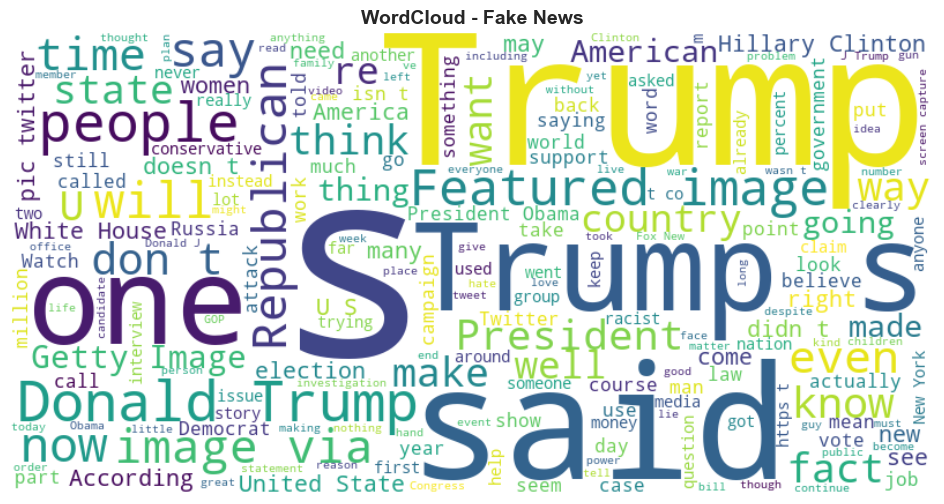

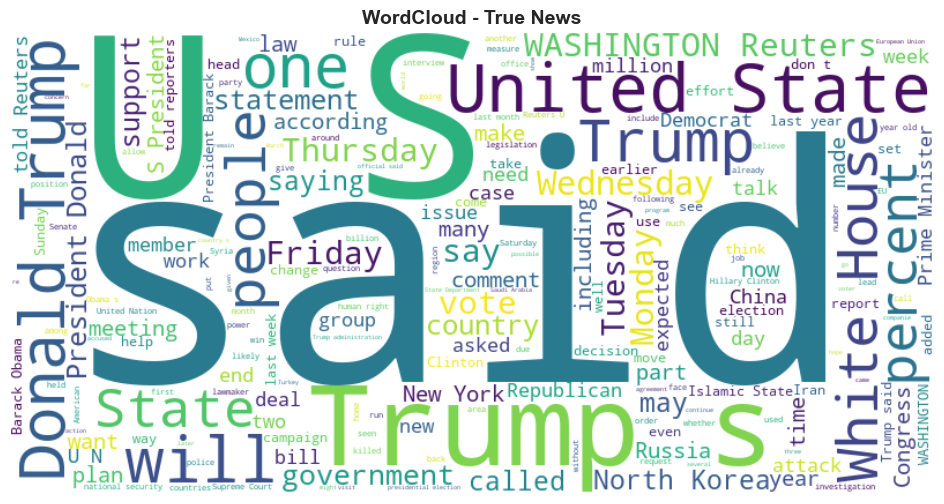

In [7]:
plot_wordclouds(df)

### Cell 9: xAI

0. ĐÁNH GIÁ TRỌNG SỐ TỪ KHÓA TỪ MÔ HÌNH CHÍNH (GLOBAL IMPORTANCE)


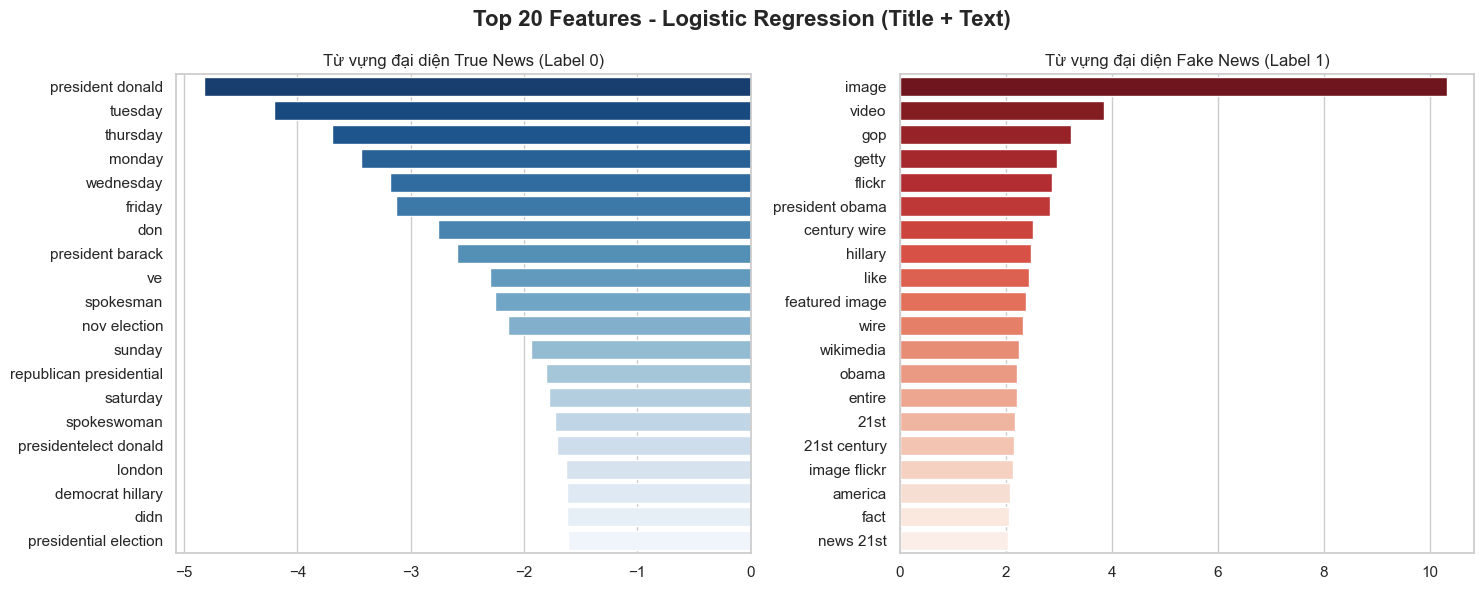


1. CHUẨN BỊ MÔ HÌNH THUẦN CHỮ CHO xAI (TRÁNH LỖI META FEATURES)

2. TRÍCH XUẤT LỖI TỪ MÔ HÌNH GỐC VÀ CHẠY LIME RA CSV
Tổng số sai: 88 | False Positives: 10 | False Negatives: 78

📌 TOP 10 FALSE POSITIVES (Thật đoán thành Giả):


,Title,Text,True Label,Predicted
25528,Britain's 'thrilled' Prince Harry announces he...,LONDON (Reuters) - Britain s Prince Harry and ...,0,1
25529,"From blind date to Botswana's stars, Prince Ha...",LONDON (Reuters) - Just four weeks after a bli...,0,1
25877,Prince Harry's engagement shows British monarc...,LONDON (Reuters) - King Edward VIII sacrificed...,0,1
26418,Muslim holds ancient key to Jesus tomb site in...,"JERUSALEM (Reuters) - As dark falls, Adeeb Jou...",0,1
26965,"From life as thugs to baking, El Salvador's ex...",SAN SALVADOR (Reuters) - Gang life in the poor...,0,1
28191,China warns against livestreaming after 'rooft...,BEIJING (Reuters) - A young Chinese climbing e...,0,1
28594,Pictures of the Year: A picture and its story,(Reuters) - Reuters photographers witnessed th...,0,1
30588,"Besieged Syrians eating trash, fainting from h...",GENEVA (Reuters) - Syrians in the besieged enc...,0,1
31537,Google broadens takedown of extremist YouTube ...,SAN FRANCISCO (Reuters) - Alphabet Inc s Googl...,0,1
31569,Suitcase of sapphires and other gems worth 1 m...,LONDON (Reuters) - British police were hunting...,0,1



📌 TOP 10 FALSE NEGATIVES (Giả đoán thành Thật):


,Title,Text,True Label,Predicted
28614,"Marco Rubio Grows A Spine, Blasts Trump For T...",Alleged president Donald Trump announced on hi...,1,0
28687,World Leaders Decide They Don’t Need The U.S....,"When it comes to the topic of climate change, ...",1,0
28848,Trump Humiliated By Being Forced To Sign Russ...,Amateur president Donald Trump signed was for...,1,0
28905,"32 Million Uninsured, Premiums To Double If O...",A new report released by the Congressional Bud...,1,0
28910,Senate Gives Trump Jr. Ultimatum: Respond By ...,The Senate Judiciary Committee just gave forme...,1,0
28961,Trump Considering Firing Sessions And Replaci...,"On Saturday, amateur president Donald Trump wh...",1,0
28971,Trump Administration Gets Ready To Come After...,Because there s totally nothing else better fo...,1,0
29071,James Comey Will Testify Thursday: What Will ...,Everyone is in anticipation for Thursday becau...,1,0
29099,TRUMP EFFECT? ONLY DAYS AFTER MEETING With Pre...,Flashback to February 18. 201: In a remarkable...,1,0
29103,JUDGE JEANINE: “America is Back but the Presid...,Judge Jeanine Pirro s Opening Statement focuse...,1,0



⏳ Đang chạy phân tích LIME hàng loạt cho 20 bài báo (Vui lòng đợi vài giây)...
✅ Đã phân tích xong! File CSV báo cáo được lưu tại: ../results/lime_error_analysis_top20.csv

[XEM TRƯỚC BẢNG KẾT QUẢ XUẤT CSV CHI TIẾT]


,Nhãn_Thực_Tế,Mô_Hình_Đoán,Từ_Khóa_Kéo_Về_Fake,Từ_Khóa_Kéo_Về_True
0,True News,Fake News,like (0.126) | know (0.082) | image (0.077) | ...,london (-0.074) | britain (-0.056) | year (-0....
1,True News,Fake News,like (0.068) | really (0.061) | got (0.057) | ...,london (-0.064) | britain (-0.057) | harry (-0...
2,True News,Fake News,century (0.123) | like (0.074) | time (0.039) ...,royal (-0.068) | british (-0.057) | year (-0.0...
3,True News,Fake News,century (0.149) | muslim (0.096) | entire (0.0...,jerusalem (-0.128) | city (-0.060) | key (-0.0...
4,True News,Fake News,life (0.098) | lost (0.037) | gun (0.031) | go...,gang (-0.072)



3. ĐÁNH GIÁ TỔNG THỂ TỪ KHÓA BẰNG SHAP SUMMARY PLOT

--- PHÂN TÍCH SHAP TỔNG THỂ ---
Đang tính toán SHAP values ...
Đang vẽ biểu đồ SHAP Summary Plot...


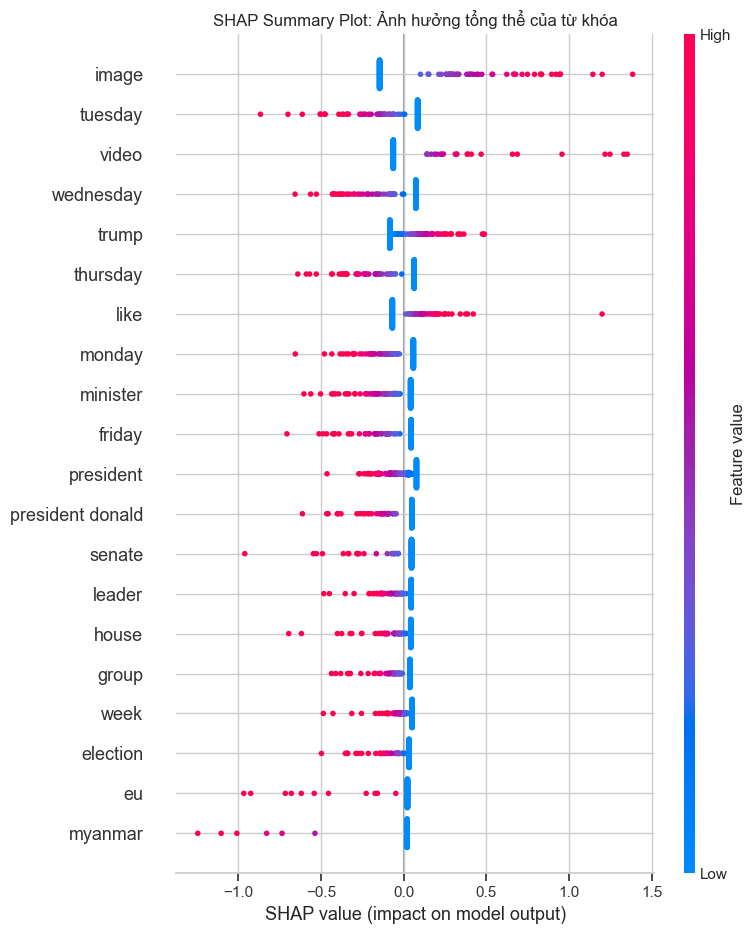

In [8]:
import importlib
import xai_utils
import model_utils
importlib.reload(xai_utils)
importlib.reload(model_utils)
import numpy as np
import pandas as pd
import textwrap
from sklearn.linear_model import LogisticRegression

print("======================================================")
print("0. ĐÁNH GIÁ TRỌNG SỐ TỪ KHÓA TỪ MÔ HÌNH CHÍNH (GLOBAL IMPORTANCE)")
print("======================================================")
model_utils.plot_top_features(tfidf_title_text, lr_model_title_text, "Logistic Regression (Title + Text)")

print("\n======================================================")
print("1. CHUẨN BỊ MÔ HÌNH THUẦN CHỮ CHO xAI (TRÁNH LỖI META FEATURES)")
print("======================================================")

X_train_title_text_strings = df.loc[train_idx, 'title_text_clean'].values
y_train = df.loc[train_idx, 'label'].values

X_train_pure_tfidf = tfidf_title_text.transform(X_train_title_text_strings)

lr_xai_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_xai_model.fit(X_train_pure_tfidf, y_train)

print("\n======================================================")
print("2. TRÍCH XUẤT LỖI TỪ MÔ HÌNH GỐC VÀ CHẠY LIME RA CSV")
print("======================================================")

# LẤY DỰ ĐOÁN TỪ MÔ HÌNH GỐC (Mô hình có 5003 features)
y_pred_main = lr_model_title_text.predict(X_test_title_text) 
y_test = df.loc[test_idx, 'label'].values

top10_fp, top10_fn = model_utils.analyze_errors(df, test_idx, y_test, y_pred_main)
top20_actual_errors = pd.concat([top10_fp, top10_fn])

if len(top20_actual_errors) > 0:
    csv_path = '../results/lime_error_analysis_top20.csv'
    
    # Dùng mô hình thuần chữ (lr_xai_model) làm Proxy để bóc tách từ khóa cho các mẫu lỗi này
    lime_report_df = xai_utils.export_batch_lime_to_csv(top20_actual_errors, lr_xai_model, tfidf_title_text, csv_path)
    
    print("\n[XEM TRƯỚC BẢNG KẾT QUẢ XUẤT CSV CHI TIẾT]")
    display(lime_report_df[['Nhãn_Thực_Tế', 'Mô_Hình_Đoán', 'Từ_Khóa_Kéo_Về_Fake', 'Từ_Khóa_Kéo_Về_True']].head(5))
else:
    print("Không có lỗi nào để phân tích.")

print("\n======================================================")
print("3. ĐÁNH GIÁ TỔNG THỂ TỪ KHÓA BẰNG SHAP SUMMARY PLOT")
print("======================================================")
X_sample_text_strings = df.loc[test_idx, 'title_text_clean'].sample(n=200, random_state=42)
xai_utils.explain_with_shap(lr_xai_model, tfidf_title_text, X_sample_text_strings)

### Cell 10:Lưu mô hình

In [9]:
import joblib
import os

# Tạo thư mục lưu mô hình (nếu chưa có)
os.makedirs('../models', exist_ok=True)

# Lưu bộ mã hóa TF-IDF và mô hình Logistic Regression
joblib.dump(tfidf_title_text, '../models/tfidf_title_text.pkl')
joblib.dump(lr_xai_model, '../models/lr_xai_model.pkl') # Đảm bảo tên biến model khớp với biến bạn đã train

print("✅ Đã xuất mô hình và TF-IDF thành công vào thư mục ../models!")

✅ Đã xuất mô hình và TF-IDF thành công vào thư mục ../models!
